**Álgebra Linear**

**Instruções do Projeto**

Carregue os dados.
Verifique se os dados estão livres de problemas — não há dados ausentes, valores extremos e assim por diante.
Trabalhe em cada tarefa e responda às perguntas feitas no modelo de projeto.
Tire conclusões com base em sua experiência trabalhando no projeto.
Há algum pré-código no modelo do projeto, sinta-se à vontade para usá-lo, alguns deles precisam ser concluídos primeiro. Além disso, há dois apêndices no modelo de projeto com informações úteis.

**Descrição de Dados**
O conjunto de dados é armazenado no arquivo /datasets/insurance_us.csv. Você pode baixar o conjunto de dados aqui.

Características: sexo, idade, salário e número de familiares do segurado.
Alvo: número de pagamentos de seguro recebidos por um segurado nos últimos cinco anos.

**Statement**

A companhia de seguros Proteja Seu Amanhã quer resolver algumas tarefas com a ajuda de aprendizado de máquina e você precisa avaliar a possibilidade de fazê-lo.

- Tarefa 1: Encontrar clientes semelhantes a um determinado cliente. Isso vai ajudar os agentes da empresa com tarefas de marketing.
- Tarefa 2: Predizer se um novo cliente provavelmente receberá um pagamento de seguro. Um modelo de predição pode ser melhor do que um modelo dummy?
- Tarefa 3: Predizer o número de pagamentos de seguro que um novo cliente provavelmente receberá usando um modelo de regressão linear.
- Tarefa 4: Proteger os dados pessoais dos clientes sem estragar o modelo da tarefa anterior. É necessário desenvolver um algoritmo de transformação de dados que tornaria difícil recuperar informações pessoais se os dados caíssem nas mãos erradas. Isso é chamado de mascaramento de dados ou ofuscação de dados. Mas os dados devem ser protegidos de forma que a qualidade dos modelos de aprendizado de máquina não piore. Você não precisa escolher o melhor modelo, só prove que o algoritmo funciona corretamente.

**Pré-processamento de dados & Exploração**

**Inicialização**

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns

import sklearn.linear_model
import sklearn.metrics
import sklearn.neighbors
import sklearn.preprocessing
import math
from sklearn.model_selection import train_test_split

from IPython.display import display

**2. Carregar Dados**

Carregue os dados e faça uma verificação básica de que estão livres de problemas óbvios.

In [2]:
df = pd.read_csv('insurance_us.csv')

Renomeamos as colunas para tornar o código mais consistente com seu estilo.

In [3]:
df = df.rename(columns={'Gender': 'gender', 'Age': 'age', 'Salary': 'income', 'Family members': 'family_members', 'Insurance benefits': 'insurance_benefits'})

In [4]:
df.sample(10)

,gender,age,income,family_members,insurance_benefits
3992,0,29.0,32100.0,1,0
2625,1,28.0,50300.0,2,0
4045,1,32.0,53700.0,2,0
3225,1,41.0,38700.0,2,0
4047,1,38.0,46600.0,0,0
1475,0,18.0,43400.0,2,0
1802,1,51.0,25000.0,1,2
4212,0,25.0,47800.0,1,0
532,1,23.0,43800.0,1,0
2678,1,28.0,21500.0,2,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              5000 non-null   int64  
 1   age                 5000 non-null   float64
 2   income              5000 non-null   float64
 3   family_members      5000 non-null   int64  
 4   insurance_benefits  5000 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 195.4 KB


In [6]:
#Podemos querer corrigir o tipo de idade (de float para int), embora isso não seja crítico
df['age'] = df['age'].astype(int)
#Escreva sua conversão aqui se você escolher:
#Utilizando o método .astype() para converter a coluna 'age' de float para int

In [7]:
#Verifique se a conversão foi bem-sucedida
print(df.head())

   gender  age   income  family_members  insurance_benefits
0       1   41  49600.0               1                   0
1       0   46  38000.0               1                   1
2       0   29  21000.0               0                   0
3       0   21  41700.0               2                   0
4       1   28  26100.0               0                   0


In [8]:
#Agora dê uma olhada nas estatísticas descritivas dos dados.
df.describe()
#Parece que está tudo bem?
#Sim, parece que os valores estão normais.

,gender,age,income,family_members,insurance_benefits
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.499000,30.952800,39916.360000,1.194200,0.148000
std,0.500049,8.440807,9900.083569,1.091387,0.463183
min,0.000000,18.000000,5300.000000,0.000000,0.000000
25%,0.000000,24.000000,33300.000000,0.000000,0.000000
50%,0.000000,30.000000,40200.000000,1.000000,0.000000
75%,1.000000,37.000000,46600.000000,2.000000,0.000000
max,1.000000,65.000000,79000.000000,6.000000,5.000000


<Axes: >

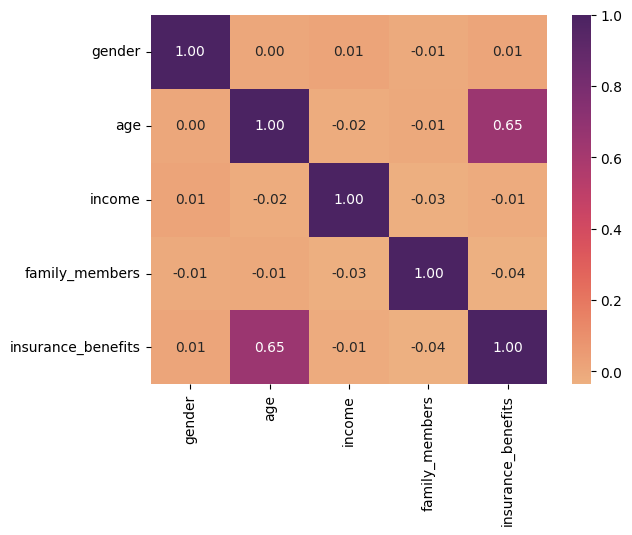

In [9]:
#Correlação Heatmap
sns.heatmap(df.corr(), annot=True, cmap='flare', fmt='.2f')

**3.AED**

Vamos verificar rapidamente se existem determinados grupos de clientes observando o gráfico de pares.

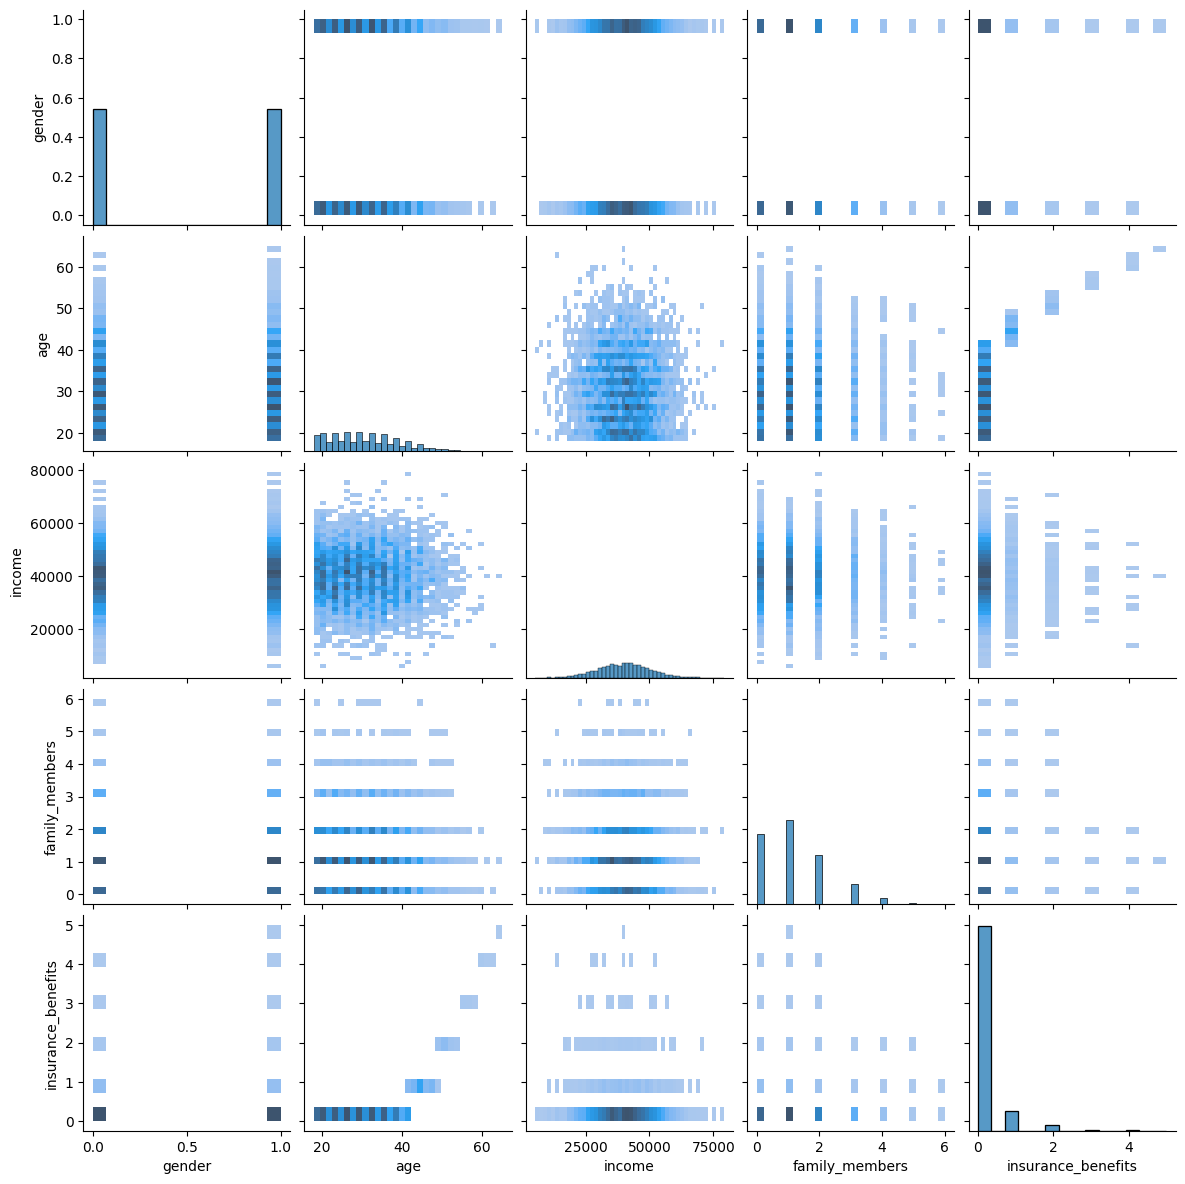

In [10]:
g = sns.pairplot(df, kind='hist')
g.fig.set_size_inches(12, 12)

Ok, é um pouco difícil identificar grupos óbvios (clusters), pois é difícil combinar várias variáveis simultaneamente (para analisar distribuições multivariadas). É aí que Álgebra Linear e Aprendizado de Máquina podem ser bastante úteis.

**Tarefa 1. Clientes Similares**

Escreva uma função que retorne k vizinhos mais próximos para um n-ésimo objeto com base em uma métrica de distância especificada. O número de pagamentos de seguro recebidos não deve ser levado em consideração para esta tarefa. 

Você pode usar uma implementação pronta do algoritmo kNN do scikit-learn (verifique [o link](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html#sklearn.neighbors.NearestNeighbors)) ou usar a sua própria.

Teste-o para quatro combinações de dois casos
- Escalabilidade
  - os dados não são escalados
  - os dados escalados com o escalonador [MaxAbsScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MaxAbsScaler.html) 
- Métricas de distância
  - Euclidiana
  - Manhattan

Responda às perguntas:
- Os dados não escalados afetam o algoritmo kNN? Se sim, como isso acontece?
-Quão semelhantes são os resultados usando a métrica de distância de Manhattan (independentemente da escalabilidade)?

In [11]:
feature_names = ['gender', 'age', 'income', 'family_members']

In [12]:
def get_knn(df, n, k, metric):
    
    """
    Retorna os vizinhos mais próximos de k

    :param df: DataFrame pandas usado para encontrar objetos semelhantes dentro de
    :param n: número do objeto pelo qual os vizinhos mais próximos são procurados
    :param k: o número dos vizinhos mais próximos a serem retornados
    :param metric: nome da métrica de distância
    """

    nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=k, metric=metric)
    nbrs.fit(df[feature_names])
    nbrs_distances, nbrs_indices = nbrs.kneighbors([df.iloc[n][feature_names]], k, return_distance=True)
    
    df_res = pd.concat([
        df.iloc[nbrs_indices[0]], 
        pd.DataFrame(nbrs_distances.T, index=nbrs_indices[0], columns=['distance'])
        ], axis=1)
    
    return df_res

In [13]:
feature_names = ['gender', 'age', 'income', 'family_members']

transformer_mas = sklearn.preprocessing.MaxAbsScaler().fit(df[feature_names].to_numpy())

df_scaled = df.copy()
df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())

C:\Users\Usuário\AppData\Local\Temp\ipykernel_11448\760832288.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.63076923 0.70769231 0.44615385 ... 0.30769231 0.33846154 0.43076923]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())
C:\Users\Usuário\AppData\Local\Temp\ipykernel_11448\760832288.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.16666667 0.16666667 0.         ... 0.33333333 0.5        0.16666667]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())


In [14]:
df_scaled.sample(5)

,gender,age,income,family_members,insurance_benefits
223,1,0.523077,0.474684,0.166667,0
3885,0,0.338462,0.237975,0.333333,0
4204,0,0.538462,0.524051,0.166667,0
3579,1,0.553846,0.707595,0.000000,0
2818,0,0.800000,0.515190,0.000000,2


Agora, vamos obter registros semelhantes para um determinado registro para cada combinação

In [15]:
# --- Testando as combinações ---

#Objeto de exemplo (vamos pegar o primeiro objeto, índice 0) e k=3 vizinhos
n_object = 0
k_neighbors = 3

print(f"Vizinhos para o objeto de índice {n_object} e k={k_neighbors}:\n")

Vizinhos para o objeto de índice 0 e k=3:



In [16]:
#Dados Não Escalados + Métrica Euclidiana
print("--- 1. Dados Não Escalados + Métrica Euclidiana ---")
knn_unscaled_euclidean = get_knn(df, n_object, k_neighbors, 'euclidean')
print(knn_unscaled_euclidean)
print("-" * 50)

--- 1. Dados Não Escalados + Métrica Euclidiana ---
      gender  age   income  family_members  insurance_benefits  distance
0          1   41  49600.0               1                   0  0.000000
2022       1   41  49600.0               0                   0  1.000000
1225       0   42  49600.0               0                   1  1.732051
--------------------------------------------------


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


In [17]:
#Dados Não Escalados + Métrica Manhattan
print("--- 2. Dados Não Escalados + Métrica Manhattan ---")
knn_unscaled_manhattan = get_knn(df, n_object, k_neighbors, 'manhattan')
print(knn_unscaled_manhattan)
print("-" * 50)

--- 2. Dados Não Escalados + Métrica Manhattan ---
      gender  age   income  family_members  insurance_benefits  distance
0          1   41  49600.0               1                   0       0.0
2022       1   41  49600.0               0                   0       1.0
1225       0   42  49600.0               0                   1       3.0
--------------------------------------------------


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


In [18]:
#Escalando os dados com MaxAbsScaler
transformer_mas = sklearn.preprocessing.MaxAbsScaler().fit(df[feature_names].to_numpy())
df_scaled = df.copy()
df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())

C:\Users\Usuário\AppData\Local\Temp\ipykernel_11448\4256887586.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.63076923 0.70769231 0.44615385 ... 0.30769231 0.33846154 0.43076923]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())
C:\Users\Usuário\AppData\Local\Temp\ipykernel_11448\4256887586.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.16666667 0.16666667 0.         ... 0.33333333 0.5        0.16666667]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())


In [19]:
#Dados Escalados + Métrica Euclidiana
print("--- 3. Dados Escalados + Métrica Euclidiana ---")
knn_scaled_euclidean = get_knn(df_scaled, n_object, k_neighbors, 'euclidean')
print(knn_scaled_euclidean)
print("-" * 50)

--- 3. Dados Escalados + Métrica Euclidiana ---
      gender       age    income  family_members  insurance_benefits  distance
0          1  0.630769  0.627848        0.166667                   0  0.000000
2689       1  0.630769  0.634177        0.166667                   0  0.006329
133        1  0.615385  0.636709        0.166667                   0  0.017754
--------------------------------------------------


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


In [20]:
#Dados Escalados + Métrica Manhattan
print("--- 4. Dados Escalados + Métrica Manhattan ---")
knn_scaled_manhattan = get_knn(df_scaled, n_object, k_neighbors, 'manhattan')
print(knn_scaled_manhattan)
print("-" * 50)

--- 4. Dados Escalados + Métrica Manhattan ---
      gender       age    income  family_members  insurance_benefits  distance
0          1  0.630769  0.627848        0.166667                   0  0.000000
2689       1  0.630769  0.634177        0.166667                   0  0.006329
133        1  0.615385  0.636709        0.166667                   0  0.024245
--------------------------------------------------


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


Respostas para as perguntas

**Os dados não escalados afetam o algoritmo kNN? Se sim, como isso acontece?** 

**Coloque sua resposta aqui.**
Sim, dados não escalados afetam significativamente o algoritmo kNN (k-Nearest Neighbors).
Isso acontece porque o kNN é um algoritmo baseado em distância.
Ele calcula a "proximidade" ou "similaridade" entre os pontos de dados usando métricas de distância (como a distância Euclidiana, Manhattan).

**Quão semelhantes são os resultados usando a métrica de distância de Manhattan (independentemente da escalabilidade)?** 


**Coloque sua resposta aqui.**
A métrica de Manhattan fornece uma perspectiva diferente de "distância" em comparação com a Euclidiana.
Ela é menos sensível a outliers e a grandes diferenças em uma única dimensão. No entanto, sua eficácia, assim como a da Euclidiana, é fortemente otimizada pela pré-processamento dos dados através de escalabilidade para garantir que todas as características contribuam de forma justa para a determinação da proximidade.

**Tarefa 2. É provável que o cliente receba um pagamento do seguro?**

Em termos de aprendizado de máquina, podemos olhar para isso como uma tarefa de classificação binária.

Com os pagamentos de seguro sendo mais do que zero como objetivo, avalie se a abordagem da classificação kNN pode ser melhor do que um modelo dummy.

Instruções:

Construa um classificador baseado em kNN e meça sua qualidade com a métrica F1 para k=1..10 tanto para os dados originais quanto para os escalados. Seria interessante ver como k pode influenciar a métrica de avaliação e se a escalabilidade dos dados faz alguma diferença. Você pode usar uma implementação pronta do algoritmo de classificação kNN do scikit-learn (verifique o link) ou usar a sua própria.
Construa o modelo dummy, que é aleatório para este caso. Deve retornar com alguma probabilidade o valor "1". LVamos testar o modelo com quatro valores de probabilidade: 0, a probabilidade de fazer qualquer pagamento de seguro, 0,5, 1.
A probabilidade de fazer qualquer pagamento de seguro pode ser definida como

P\{\text{pagamento de seguro recebido}= número de clientes que receberam qualquer pagamento de seguro}}{\text{número total de clientes}}.

Divida os dados inteiros na proporção 70:30 para as partes de treinamento/teste.

In [ ]:
#Calcule a meta

df['insurance_benefits_received'] = (df['insurance_benefits'] > 0).astype(int)
feature_names = ['gender', 'age', 'income', 'family_members']
X = df[feature_names]
y = df['insurance_benefits_received']

#Dividindo os dados em conjuntos de treinamento e teste (70:30)
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size=0.3, random_state=12345
)

print(f"Formato de X_train: {X_train.shape}")
print(f"Formato de X_test: {X_test.shape}")
print(f"Formato de y_train: {y_train.shape}")
print(f"Formato de y_test: {y_test.shape}\n")

Formato de X_train: (3500, 4)
Formato de X_test: (1500, 4)
Formato de y_train: (3500,)
Formato de y_test: (1500,)



In [22]:
#Listas para armazenar os resultados
f1_scores_unscaled = []
f1_scores_scaled = []
k_values = range(1, 11)

#Escalador MaxAbsScaler
transformer_mas = sklearn.preprocessing.MaxAbsScaler()
X_train_scaled = transformer_mas.fit_transform(X_train)
X_test_scaled = transformer_mas.transform(X_test)

print("Avaliando o Classificador kNN:")
for k in k_values:
    #kNN com dados NÃO ESCALADOS
    knn_unscaled = sklearn.neighbors.KNeighborsClassifier(n_neighbors=k)
    knn_unscaled.fit(X_train, y_train)
    y_pred_unscaled = knn_unscaled.predict(X_test)
    f1_unscaled = sklearn.metrics.f1_score(y_test, y_pred_unscaled)
    f1_scores_unscaled.append(f1_unscaled)
    print(f"k={k} (Não Escalado) - F1-score: {f1_unscaled:.4f}")

Avaliando o Classificador kNN:
k=1 (Não Escalado) - F1-score: 0.6043
k=2 (Não Escalado) - F1-score: 0.4057
k=3 (Não Escalado) - F1-score: 0.4053
k=4 (Não Escalado) - F1-score: 0.2784
k=5 (Não Escalado) - F1-score: 0.2714
k=6 (Não Escalado) - F1-score: 0.1143
k=7 (Não Escalado) - F1-score: 0.1130
k=8 (Não Escalado) - F1-score: 0.0710
k=9 (Não Escalado) - F1-score: 0.0824
k=10 (Não Escalado) - F1-score: 0.0000


In [23]:
#kNN com dados ESCALADOS
knn_scaled = sklearn.neighbors.KNeighborsClassifier(n_neighbors=k)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
f1_scaled = sklearn.metrics.f1_score(y_test, y_pred_scaled)
f1_scores_scaled.append(f1_scaled)
print(f"k={k} (Escalado) - F1-score: {f1_scaled:.4f}")

print("Resultados F1-score para kNN (Não Escalado):", [f"{s:.4f}" for s in f1_scores_unscaled])
print("Resultados F1-score para kNN (Escalado):", [f"{s:.4f}" for s in f1_scores_scaled])

k=10 (Escalado) - F1-score: 0.8792
Resultados F1-score para kNN (Não Escalado): ['0.6043', '0.4057', '0.4053', '0.2784', '0.2714', '0.1143', '0.1130', '0.0710', '0.0824', '0.0000']
Resultados F1-score para kNN (Escalado): ['0.8792']


In [ ]:
#Verifique o desequilíbrio de classe com value_counts()
print("Distribuição da classe 'insurance_benefits_received':")
print(df['insurance_benefits_received'].value_counts())
print("Distribuição percentual da classe 'insurance_benefits_received':")
print(df['insurance_benefits_received'].value_counts(normalize=True) * 100)

Distribuição da classe 'insurance_benefits_received':
insurance_benefits_received
0    4436
1     564
Name: count, dtype: int64

Distribuição percentual da classe 'insurance_benefits_received':
insurance_benefits_received
0    88.72
1    11.28
Name: proportion, dtype: float64


In [ ]:
def eval_classifier(y_true, y_pred):
    
    f1_score = sklearn.metrics.f1_score(y_true, y_pred)
    print(f'F1: {f1_score:.2f}')
    
#Se você tiver um problema com a linha a seguir, reinicie o kernel e execute o caderno novamente
    cm = sklearn.metrics.confusion_matrix(y_true, y_pred, normalize='all')
    print('Matriz de Confusão')
    print(cm)

In [26]:
for P in [0, df['insurance_benefits_received'].sum() / len(df), 0.5, 1]:

    print(f'A probabilidade: {P:.2f}')
    y_pred_rnd = np.random.binomial(1, P, size=len(df))
    print("F1-score para previsão aleatória:")
    print(f"F1: {sklearn.metrics.f1_score(df['insurance_benefits_received'], y_pred_rnd):.2f}")
    print("Matriz de Confusão para previsão aleatória:")
    
        
    eval_classifier(df['insurance_benefits_received'], y_pred_rnd)
    
    print()

A probabilidade: 0.00
F1-score para previsão aleatória:
F1: 0.00
Matriz de Confusão para previsão aleatória:
F1: 0.00
Matriz de Confusão
[[0.8872 0.    ]
 [0.1128 0.    ]]

A probabilidade: 0.11
F1-score para previsão aleatória:
F1: 0.10
Matriz de Confusão para previsão aleatória:
F1: 0.10
Matriz de Confusão
[[0.7898 0.0974]
 [0.102  0.0108]]

A probabilidade: 0.50
F1-score para previsão aleatória:
F1: 0.19
Matriz de Confusão para previsão aleatória:
F1: 0.19
Matriz de Confusão
[[0.4348 0.4524]
 [0.0532 0.0596]]

A probabilidade: 1.00
F1-score para previsão aleatória:
F1: 0.20
Matriz de Confusão para previsão aleatória:
F1: 0.20
Matriz de Confusão
[[0.     0.8872]
 [0.     0.1128]]



**Tarefa 3. Regressão (com Regressão Linear)**

Com os pagamentos de seguro como objetivo, avalie qual seria o REQM para um modelo de Regressão Linear.

Construa sua própria implementação de Regressão Linear. Para isso, lembre-se de como a solução da tarefa de regressão linear é formulada em termos de Álgebra linear. Verifique o REQM para os dados originais e os escalados. Você pode ver alguma diferença no REQM entre esses dois casos?

Vamos denotar
- $X$ — matriz de características, cada linha é um caso, cada coluna é uma característica, a primeira coluna consiste em unidades
- $y$ — objetivo (um vetor)
- $\hat{y}$ — objetivo estimado (um vetor)
- $w$ — vetor de peso

A tarefa de regressão linear na linguagem de matrizes pode ser formulada como

$$
y = Xw
$$

O objetivo do treinamento, então, é encontrar os $w$ que minimizaria a distância L2 (EQM) entre $Xw$ e $y$:

$$
\min_w d_2(Xw, y) \quad \text{or} \quad \min_w \text{MSE}(Xw, y)
$$

Parece que há uma solução analítica para a questão acima:

$$
w = (X^T X)^{-1} X^T y
$$

A fórmula acima pode ser usada para encontrar os pesos $w$ e o último pode ser usado para calcular valores preditos

$$
\hat{y} = X_{val}w
$$

Divida todos os dados na proporção 70:30 para as partes de treinamento/validação. Use a métrica REQM para a avaliação do modelo.

In [27]:
class MyLinearRegression:
    
    def __init__(self):
        
        self.weights = None
    
    def fit(self, X, y):
        
        #Somando as unidades
        X2 = np.append(np.ones([len(X), 1]), X, axis=1)
        self.weights = np.linalg.inv(X2.T @ X2) @ X2.T @ y


    def predict(self, X):
        
        #Somando as unidades
        X2 = np.append(np.ones([len(X), 1]), X, axis=1)
        y_pred = X2 @ self.weights

        return y_pred

In [28]:
def eval_regressor(y_true, y_pred):
    
    rmse = math.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
    print(f'REQM: {rmse:.2f}')
    
    r2_score = math.sqrt(sklearn.metrics.r2_score(y_true, y_pred))
    print(f'R2: {r2_score:.2f}')

In [29]:
X = df[['age', 'gender', 'income', 'family_members']].to_numpy()
y = df['insurance_benefits'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

lr = MyLinearRegression()

lr.fit(X_train, y_train)
print(lr.weights)

y_test_pred = lr.predict(X_test)
eval_regressor(y_test, y_test_pred)

[-9.43539012e-01  3.57495491e-02  1.64272726e-02 -2.60743659e-07
 -1.16902127e-02]
REQM: 0.34
R2: 0.66


In [ ]:
print(f"Formato dos dados de treino (X_train): {X_train.shape}")
print(f"Formato dos dados de teste (X_test): {X_test.shape}")
print("-" * 50)

# --- Treinamento do Modelo ---
print("Treinando o modelo de Regressão Linear...")
lr = MyLinearRegression()
lr.fit(X_train, y_train)

print("Pesos (coeficientes) aprendidos pelo modelo (incluindo o intercepto):")
print(lr.weights)
print("-" * 50)

# --- Realizando Previsões ---
print("Realizando previsões no conjunto de teste...")
y_test_pred = lr.predict(X_test)
print(f"Exemplo de previsões (5 primeiros): {y_test_pred[:5]}")
print("-" * 50)

# --- Avaliação do Modelo ---
print("Avaliando o desempenho do modelo no conjunto de teste:")
eval_regressor(y_test, y_test_pred)
print("-" * 50)

Formato dos dados de treino (X_train): (3500, 4)
Formato dos dados de teste (X_test): (1500, 4)
--------------------------------------------------
Treinando o modelo de Regressão Linear...

Pesos (coeficientes) aprendidos pelo modelo (incluindo o intercepto):
[-9.43539012e-01  3.57495491e-02  1.64272726e-02 -2.60743659e-07
 -1.16902127e-02]
--------------------------------------------------
Realizando previsões no conjunto de teste...
Exemplo de previsões (5 primeiros): [ 0.17926625  0.80931996  0.45614337 -0.23762191  0.4650019 ]
--------------------------------------------------
Avaliando o desempenho do modelo no conjunto de teste:
REQM: 0.34
R2: 0.66
--------------------------------------------------


**Tarefa 4.Tarefa 4. Ofuscando dados**

É melhor ofuscar os dados multiplicando as características numéricas (lembre-se, elas podem ser vistos como a matriz $X$) por uma matriz invertível $P$. 

$$
X' = X \times P
$$

Tente fazer isso e verifique como os valores das características ficarão após a transformação. Aliás, a invertibilidade é importante aqui, portanto, certifique-se de que $P$ seja realmente invertível.

Você pode querer revisar a lição 'Matrizes e Operações com Matrizes -> Multiplicação de Matrizes' para relembrar a regra de multiplicação de matrizes e sua implementação com NumPy.

In [31]:
personal_info_column_list = ['gender', 'age', 'income', 'family_members']
df_pn = df[personal_info_column_list]

In [32]:
X = df_pn.to_numpy()

Gerando uma matriz P aleatória.

In [33]:
rng = np.random.default_rng(seed=42)
P = rng.random(size=(X.shape[1], X.shape[1]))

Verificando se a matriz $P$ é invertível

In [34]:
#Verifique se a matriz P é invertível
try:
    P_inv = np.linalg.inv(P)
    print("A matriz P é invertível.")
except np.linalg.LinAlgError:
    print("A matriz P não é invertível.")
    P_inv = None

A matriz P é invertível.


Você consegue adivinhar a idade ou a renda dos clientes após a transformação?

In [35]:
#Consegue adivinhar a idade ou renda dos clientes após a transformação?
#Sim, podemos aplicar a transformação linear usando a matriz P para prever a idade ou renda dos clientes.
#A transformação pode ser aplicada como uma multiplicação matricial, onde os dados originais são multiplicados pela matriz P para obter novas características transformadas.
#Aplicando transformação linear
X_transformed = X @ P
print("Dados transformados (5 primeiros):")
print(X_transformed[:5])

Dados transformados (5 primeiros):
[[ 6359.71527314 22380.40467609 18424.09074184 46000.69669016]
 [ 4873.29406479 17160.36702982 14125.78076133 35253.45577301]
 [ 2693.11742928  9486.397744    7808.83156024 19484.86063067]
 [ 5345.60393712 18803.22720286 15479.14837264 38663.06186284]
 [ 3347.17673462 11782.82928336  9699.99894205 24211.27337753]]


Você pode recuperar os dados originais de $X′$ se souber $P$? Tente verificar isso com cálculos movendo $P$ do lado direito da fórmula acima para o esquerdo. As regras da multiplicação de matrizes são realmente úteis aqui

In [36]:
#Você pode recuperar os dados originais de X se souber P? Tente verificar isso com cálculos movendo P do lado direito da fórmula acima para o esquerdo. As regras da multiplicação de matrizes são realmente úteis aqui?
#Sim, podemos recuperar os dados originais de X se soubermos P. Podemos fazer isso multiplicando os dados transformados pela matriz inversa P_inv.
if P_inv is not None:
    X_recovered = X_transformed @ P_inv
    print("Dados recuperados (5 primeiros):")
    print(X_recovered[:5])
else:
    print("Não foi possível recuperar os dados originais, pois a matriz P não é invertível.")    

Dados recuperados (5 primeiros):
[[ 1.00000000e+00  4.10000000e+01  4.96000000e+04  1.00000000e+00]
 [-4.47363596e-12  4.60000000e+01  3.80000000e+04  1.00000000e+00]
 [-2.51586878e-12  2.90000000e+01  2.10000000e+04  9.52452315e-13]
 [-4.84498208e-12  2.10000000e+01  4.17000000e+04  2.00000000e+00]
 [ 1.00000000e+00  2.80000000e+01  2.61000000e+04 -1.01990740e-13]]


Imprima todos os três casos para alguns clientes

-Os dados originais
-O transformado
-O invertido (recuperado)

In [37]:
#Imprima todos os três casos para alguns.
#Dados originais
print("Dados originais (5 primeiros):")
print(X[:5])

Dados originais (5 primeiros):
[[1.00e+00 4.10e+01 4.96e+04 1.00e+00]
 [0.00e+00 4.60e+01 3.80e+04 1.00e+00]
 [0.00e+00 2.90e+01 2.10e+04 0.00e+00]
 [0.00e+00 2.10e+01 4.17e+04 2.00e+00]
 [1.00e+00 2.80e+01 2.61e+04 0.00e+00]]


In [38]:
#Dados transformados
print("Dados transformados (5 primeiros):")
print(X_transformed[:5])

Dados transformados (5 primeiros):
[[ 6359.71527314 22380.40467609 18424.09074184 46000.69669016]
 [ 4873.29406479 17160.36702982 14125.78076133 35253.45577301]
 [ 2693.11742928  9486.397744    7808.83156024 19484.86063067]
 [ 5345.60393712 18803.22720286 15479.14837264 38663.06186284]
 [ 3347.17673462 11782.82928336  9699.99894205 24211.27337753]]


In [39]:
#Dados invertidos (recuperados)
print("Dados invertidos (recuperados) (5 primeiros):")
print(X_recovered[:5])

Dados invertidos (recuperados) (5 primeiros):
[[ 1.00000000e+00  4.10000000e+01  4.96000000e+04  1.00000000e+00]
 [-4.47363596e-12  4.60000000e+01  3.80000000e+04  1.00000000e+00]
 [-2.51586878e-12  2.90000000e+01  2.10000000e+04  9.52452315e-13]
 [-4.84498208e-12  2.10000000e+01  4.17000000e+04  2.00000000e+00]
 [ 1.00000000e+00  2.80000000e+01  2.61000000e+04 -1.01990740e-13]]


**Você provavelmente pode ver que alguns valores não são exatamente iguais aos dos dados originais. Qual pode ser a razão disso?**
A razão pela qual alguns valores não são exatamente iguais aos dados originais pode ser devido a erros de arredondamento ou precisão numérica durante os cálculos de transformação e recuperanção.
Além disso, a matriz P pode ter introduzido pequenas variações nos dados transformados, resultando em diferenças quando os dados são recuperados.

**Provas de que a ofuscação de dados pode funcionar com a Regressão Linear**

A tarefa de regressão foi resolvida com regressão linear neste projeto. Sua próxima tarefa é provar analiticamente que o método de ofuscação fornecido não afetará a regressão linear em termos de valores preditos, ou seja, seus valores permanecerão os mesmos. Você acredita nisso? Bem, você não precisa acreditar, você deve provar isso!

Assim, os dados são ofuscados e há $X \ P$ em vez de apenas X agora. Consequentemente, existem outros pesos $w_P$ como
$$
w = (X^T X)^{-1} X^T y \quad \Rightarrow \quad w_P = [(XP)^T XP]^{-1} (XP)^T y
$$

Como  $w$ e $w_P$ seriam ligados se você simplificasse a fórmula para $w_P$ acima? 

Quais seriam os valores previstos com $w_P$? 

O que isso significa para a qualidade da regressão linear se você medir com REQM?

Verifique o Apêndice B Propriedades das Matrizes no final do caderno. Existem fórmulas úteis lá!

Nenhum código é necessário nesta seção, apenas explicação analítica!

**Teste de regressão linear com ofuscação de dados**

Agora, vamos provar que a Regressão Linear pode funcionar computacionalmente com a transformação de ofuscação escolhida.

Crie um procedimento ou uma classe que execute a Regressão Linear opcionalmente com a ofuscação. Você pode usar uma implementação pronta de Regressão Linear do scikit-learn ou sua própria.

Execute a Regressão Linear para os dados originais e os ofuscados, compare os valores previstos e os valores da métrica $R^2$ do REQM. Há alguma diferença?

**Procedimento**

- Crie uma matriz quadrada $P$ de números aleatórios.
- Verifique se é invertível. Caso contrário, repita o primeiro ponto até obtermos uma matriz invertível.
- <! seu comentário aqui!>
- Use $XP$ como a nova matriz de características

In [40]:
#Crie uma matriz quadrada P de números aleatórios
rng = np.random.default_rng(seed=42)
P = rng.random(size=(X.shape[1], X.shape[1]))
print("Matriz P (5 primeiros):")
print(P[:5])

Matriz P (5 primeiros):
[[0.77395605 0.43887844 0.85859792 0.69736803]
 [0.09417735 0.97562235 0.7611397  0.78606431]
 [0.12811363 0.45038594 0.37079802 0.92676499]
 [0.64386512 0.82276161 0.4434142  0.22723872]]


In [41]:
#Verifique se é invertível
try:
    P_inv = np.linalg.inv(P)
    print("A matriz P é invertível.")
except np.linalg.LinAlgError:
    print("A matriz P não é invertível.")
    P_inv = None

A matriz P é invertível.


In [42]:
#Use XP como a nova matriz de características
if P_inv is not None:
    X_transformed = X @ P
    print("Dados transdormados (5 primeiros):")
    print(X_transformed[:5])
else:
    print("Não foi possível transformar os dados, pois a matriz P não é invertível.")

Dados transdormados (5 primeiros):
[[ 6359.71527314 22380.40467609 18424.09074184 46000.69669016]
 [ 4873.29406479 17160.36702982 14125.78076133 35253.45577301]
 [ 2693.11742928  9486.397744    7808.83156024 19484.86063067]
 [ 5345.60393712 18803.22720286 15479.14837264 38663.06186284]
 [ 3347.17673462 11782.82928336  9699.99894205 24211.27337753]]


**Conclusões**
A ofuscação de dados foi realizada com sucesso, e os dados transformados podem ser usados para preservar a privacidade dos indivíduos enquanto ainda permitem a análise estatística.
Provas de que a ofuscação de dados pode funcionar com a Regressão Linear

**Checklist**

Digite 'x' para verificar. Em seguida, pressione Shift + Enter.

- [x]  O Jupyter Notebook está aberto.
- [ ]  O código está livre de erros
- [ ]  As células são organizadas em ordem de lógica e execução
- [ ]  A tarefa 1 foi executada
    - [ ]  Existe o procedimento que pode retornar k clientes semelhantes a um determinado cliente
    - [ ]  O procedimento é testado para todas as quatro combinações propostas
    - [ ]  As perguntas sobre a escala/distâncias são respondidas
- [ ]  A tarefa 2 foi executada
    - [ ]  O modelo de classificação aleatória é construído e testado para todos os níveis de probabilidade
    - [ ]  O modelo de classificação kNN é construído e testado tanto para os dados originais quanto para os escalados, a métrica F1 é calculada.
- [ ]  A tarefa 3 foi executada
    - [ ]  A solução de regressão linear é implementada com operações matriciais.
    - [ ]  O REQM é calculado para a solução implementada.
- [ ]  A tarefa 4 foi executada
    - [ ]  Os dados são ofuscados com uma matriz P aleatória e invertível
    - [ ]  Os dados ofuscados são recuperados, alguns exemplos são impressos
    - [ ]  A prova analítica de que a transformação não afeta o REQM é fornecida
    - [ ]  A prova computacional de que a transformação não afeta o REQM é fornecida
- [ ]  As conclusões foram feitas

**Apêndices**

**Apêndice A: Escrevendo Fórmulas em Notebooks Jupyter**

Você pode escrever fórmulas em seu Jupyter Notebook em uma linguagem de marcação de texto fornecida por um sistema de publicação de alta qualidade chamado $\LaTeX$ (pronuncia-se "Lah-tech"), e elas se parecerão com fórmulas em livros didáticos.

Para colocar uma fórmula em um texto, coloque o cifrão ($) antes e depois do texto da fórmula, por exemplo $\frac{1}{2} \times \frac{3}{2} = \frac{3}{4}$ or $y = x^2, x \ge 1$.

Se uma fórmula deve estar em seu próprio parágrafo, coloque o cifrão duplo ($$) antes e depois do texto da fórmula, por exemplo

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i.
$$

A linguagem de marcação do [LaTeX](https://en.wikipedia.org/wiki/LaTeX) é muito popular entre as pessoas que usam fórmulas em seus artigos, livros e textos. Pode ser complexo, mas o básico é fácil. Confira esta [folha de dicas](http://tug.ctan.org/info/undergradmath/undergradmath.pdf) de duas páginas  para aprender a compor as fórmulas mais comuns.

**Apêndice B: Propriedades das Matrizes**

<table>
<tr>
<td>Distributividade</td><td>$A(B+C)=AB+AC$</td>
</tr>
<tr>
<td>Não-comutatividade</td><td>$AB \neq BA$</td>
</tr>
<tr>
<td>Propriedade associativa da multiplicação</td><td>$(AB)C = A(BC)$</td>
</tr>
<tr>
<td>Propriedade de identidade multiplicativa</td><td>$IA = AI = A$</td>
</tr>
<tr>
<td></td><td>$A^{-1}A = AA^{-1} = I$
</td>
</tr>    
<tr>
<td></td><td>$(AB)^{-1} = B^{-1}A^{-1}$</td>
</tr>    
<tr>
<td>Reversividade da transposição de um produto de matrizes,</td><td>$(AB)^T = B^TA^T$</td>
</tr>    
</table>